# Import Library

In [435]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

# Data Understanding

## Load Data

Data yang digunakan pada studi kasus ini adalah data mengenai penyakit Alzheimers.

In [436]:
data = pd.read_csv('alzheimers_disease_data.csv')
data

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,...,0,0,4.492838,1,0,0,0,0,1,XXXConfid
2145,6896,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,...,0,1,9.204952,0,0,0,0,0,1,XXXConfid
2146,6897,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,...,0,0,5.036334,0,0,0,0,0,1,XXXConfid
2147,6898,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,...,0,0,3.785399,0,0,0,0,1,1,XXXConfid


**Variabel pada Data**

In [437]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

**Identitas Pasien** 

- PatientID

**Detail Demografis**

- Age  
- Gender  
- Ethnicity  
- EducationLevel

**Faktor Gaya Hidup** 

- BMI  
- Smoking  
- AlcoholConsumption  
- PhysicalActivity  
- DietQuality  
- SleepQuality

**Riwayat Medis**  

- FamilyHistoryAlzheimers  
- CardiovascularDisease  
- Diabetes  
- Depression  
- HeadInjury  
- Hypertension

**Pengukuran Klinis** 

- SystolicBP  
- DiastolicBP  
- CholesterolTotal  
- CholesterolLDL  
- CholesterolHDL  
- CholesterolTriglycerides

**Asesmen Kognitif dan Fungsional**  

- MMSE  
- FunctionalAssessment  
- MemoryComplaints  
- BehavioralProblems  
- ADL

**Gejala**  

- Confusion  
- Disorientation  
- PersonalityChanges  
- DifficultyCompletingTasks  
- Forgetfulness

**Informasi Diagnosis** 

- Diagnosis

**Informasi Rahasia**  

- DoctorInCharge

## Exploratory Data Analysis

**Statistik Deskriptif**

In [438]:
num_data = ["Age", "BMI", "AlcoholConsumption", "PhysicalActivity", "DietQuality", "SleepQuality", "SystolicBP", "DiastolicBP", "CholesterolTotal", "CholesterolLDL", "CholesterolHDL", "CholesterolTriglycerides", "MMSE", "FunctionalAssessment", "ADL"]
data[num_data].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2149.0,74.908795,8.990221,60.000000,67.000000,75.000000,83.000000,90.000000
BMI,2149.0,27.655697,7.217438,15.008851,21.611408,27.823924,33.869778,39.992767
AlcoholConsumption,2149.0,10.039442,5.757910,0.002003,5.139810,9.934412,15.157931,19.989293
PhysicalActivity,2149.0,4.920202,2.857191,0.003616,2.570626,4.766424,7.427899,9.987429
DietQuality,2149.0,4.993138,2.909055,0.009385,2.458455,5.076087,7.558625,9.998346
SleepQuality,2149.0,7.051081,1.763573,4.002629,5.482997,7.115646,8.562521,9.999840
SystolicBP,2149.0,134.264774,25.949352,90.000000,112.000000,134.000000,157.000000,179.000000
DiastolicBP,2149.0,89.847836,17.592496,60.000000,74.000000,91.000000,105.000000,119.000000
CholesterolTotal,2149.0,225.197519,42.542233,150.093316,190.252963,225.086430,262.031657,299.993352
CholesterolLDL,2149.0,124.335944,43.366584,50.230707,87.195798,123.342593,161.733733,199.965665


*Variabel Numerik*

**EDA - Univariate Analysis**

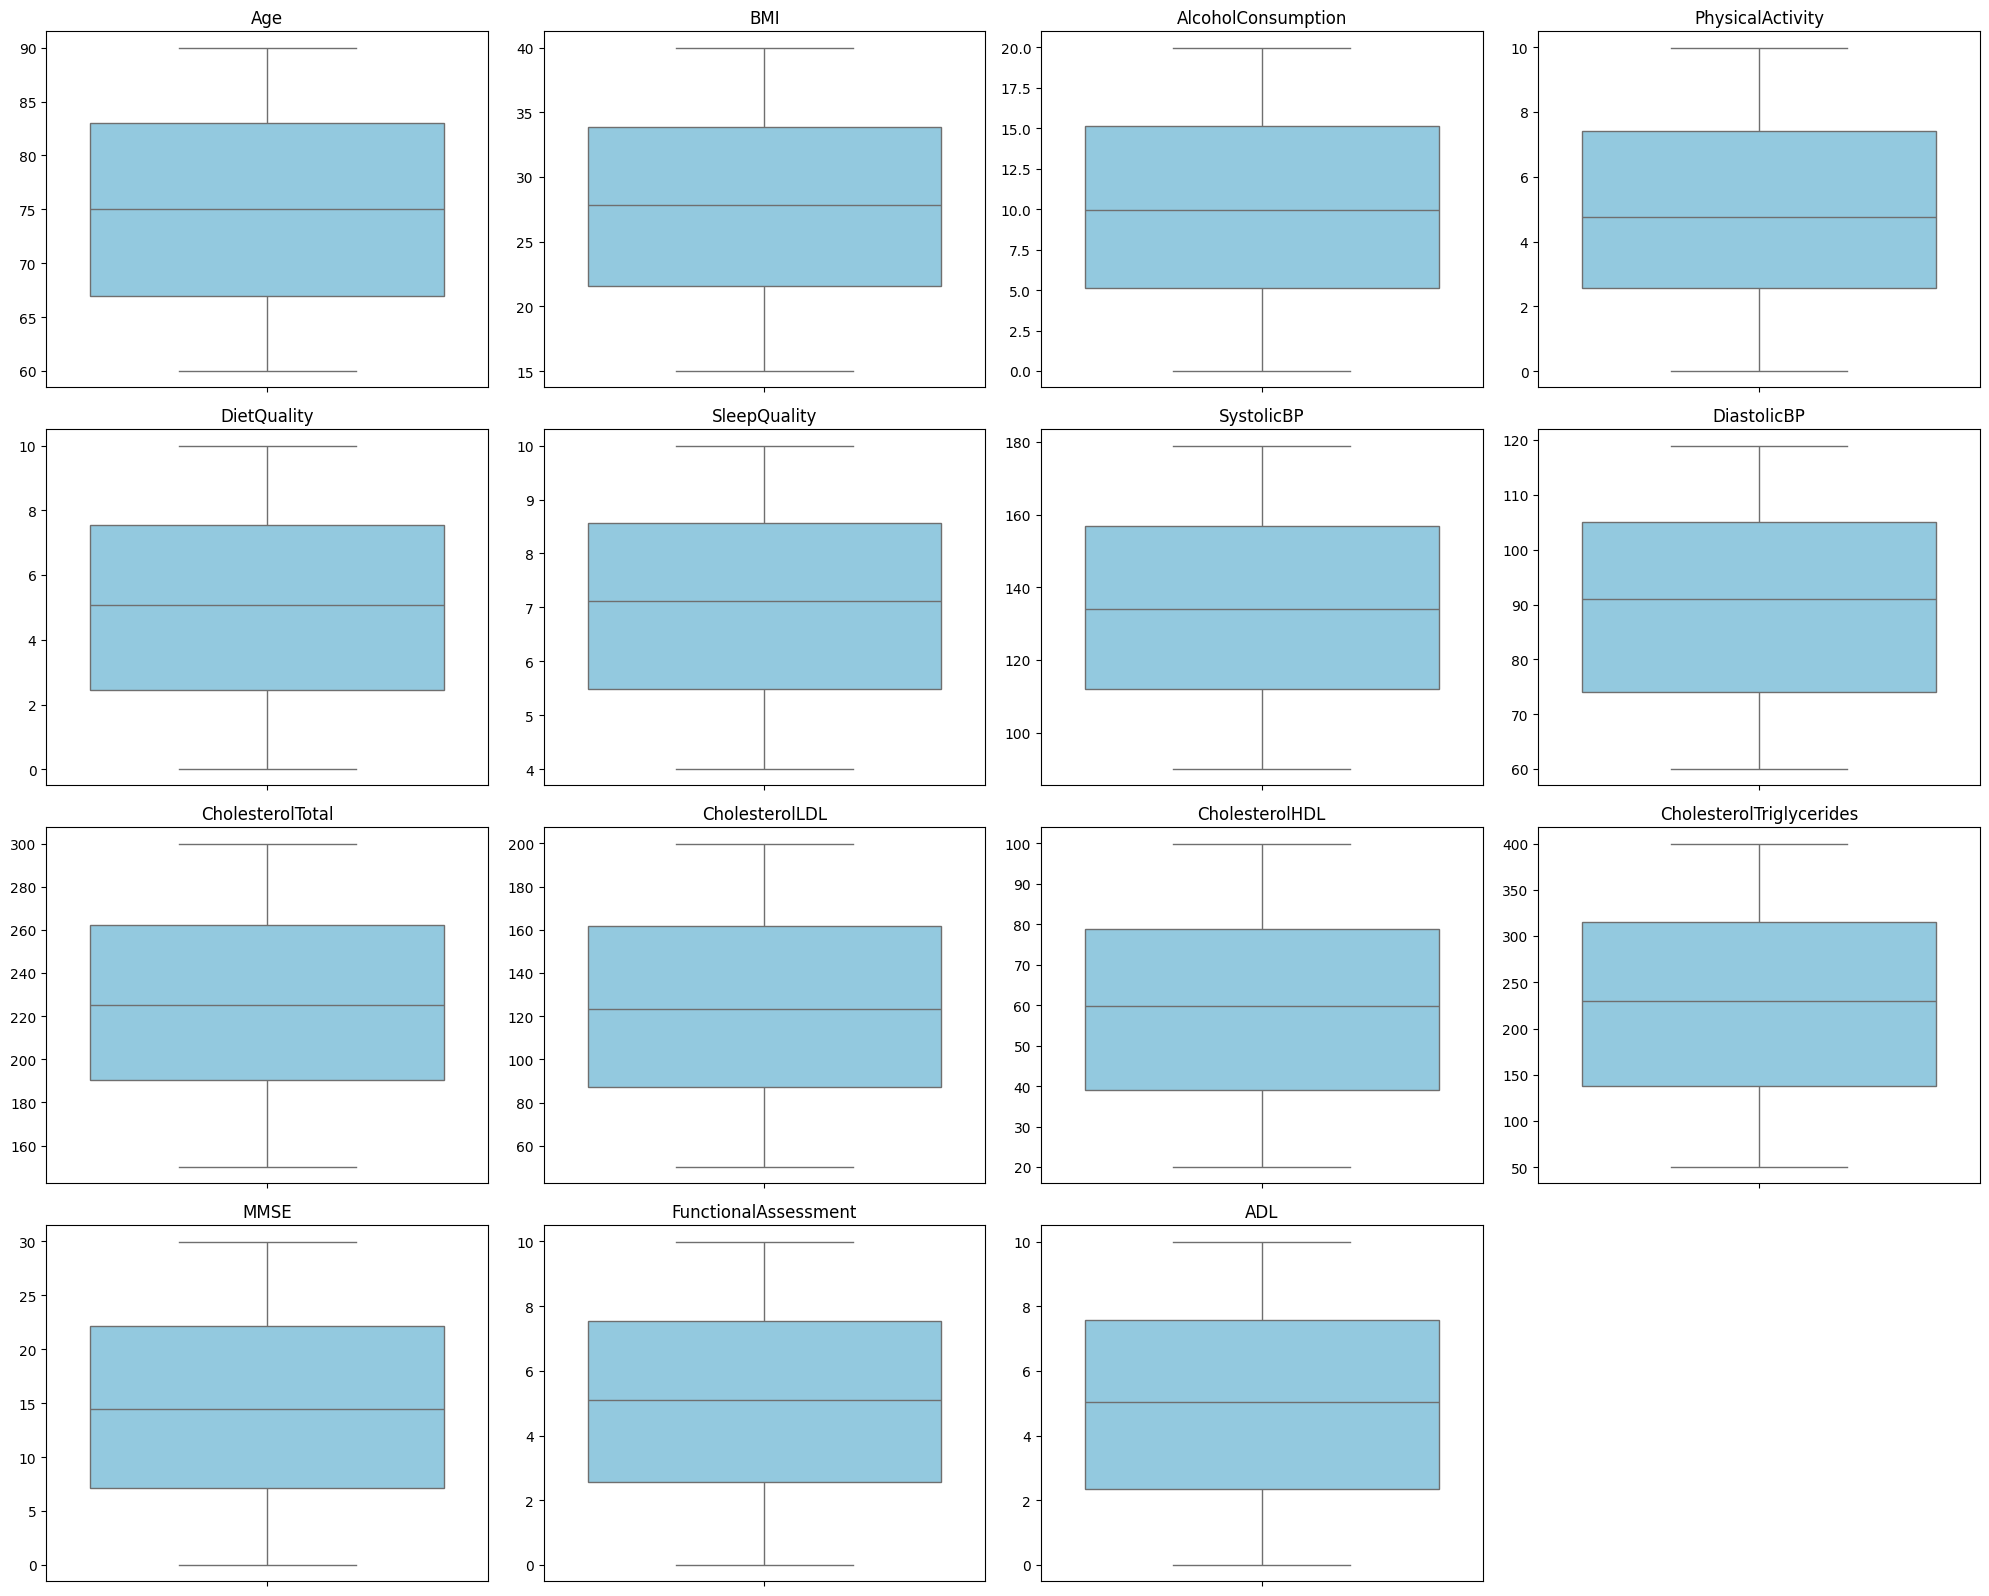

In [439]:
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(num_data):
    sns.boxplot(y=data[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Dari boxplot variabel numerik di atas, diperoleh tidak terdapat outlier pada data.

**EDA - Multivariate Analysis**

Text(0.5, 1.0, 'Correlation Matrix for Numerical Features')

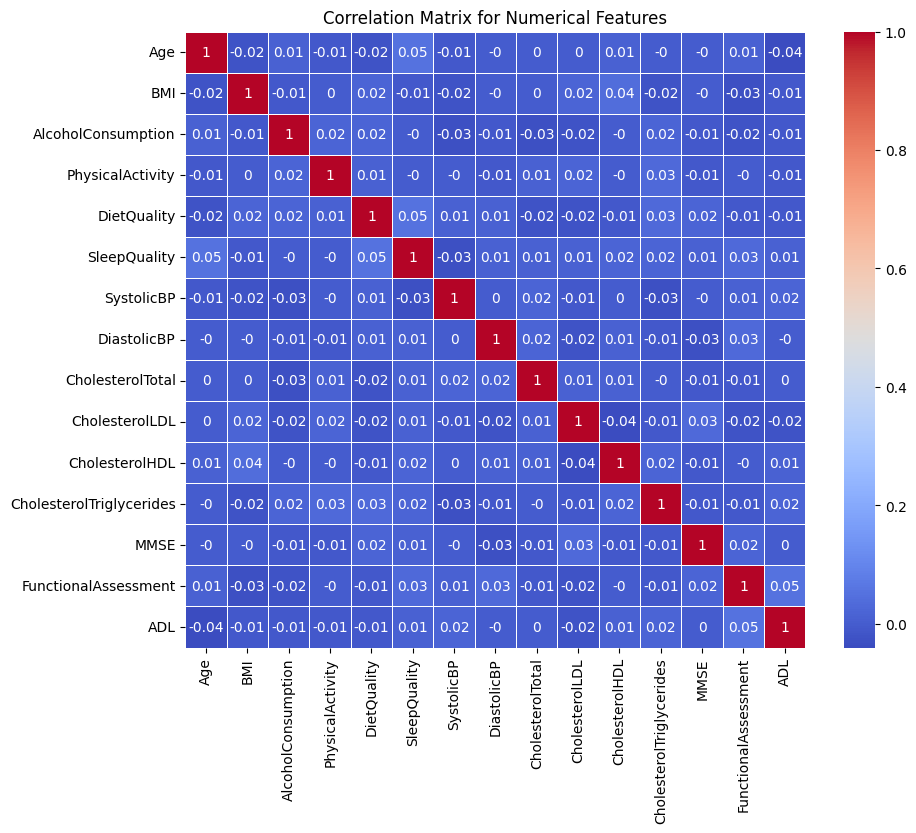

In [440]:
plt.figure(figsize=(10,8))
correlation_matrix = data[num_data].corr().round(2)

sns.heatmap(data=correlation_matrix, annot=True, cmap='coolwarm', linewidth=0.5)
plt.title("Correlation Matrix for Numerical Features")

Dari heatmap correlation di atas, diperoleh korelasi antar variabel numerik untuk semua variabel memiliki korelasi lemah, sehingga tidak terdapat indikasi multikolinearitas pada data.

*Variabel Kategorik*

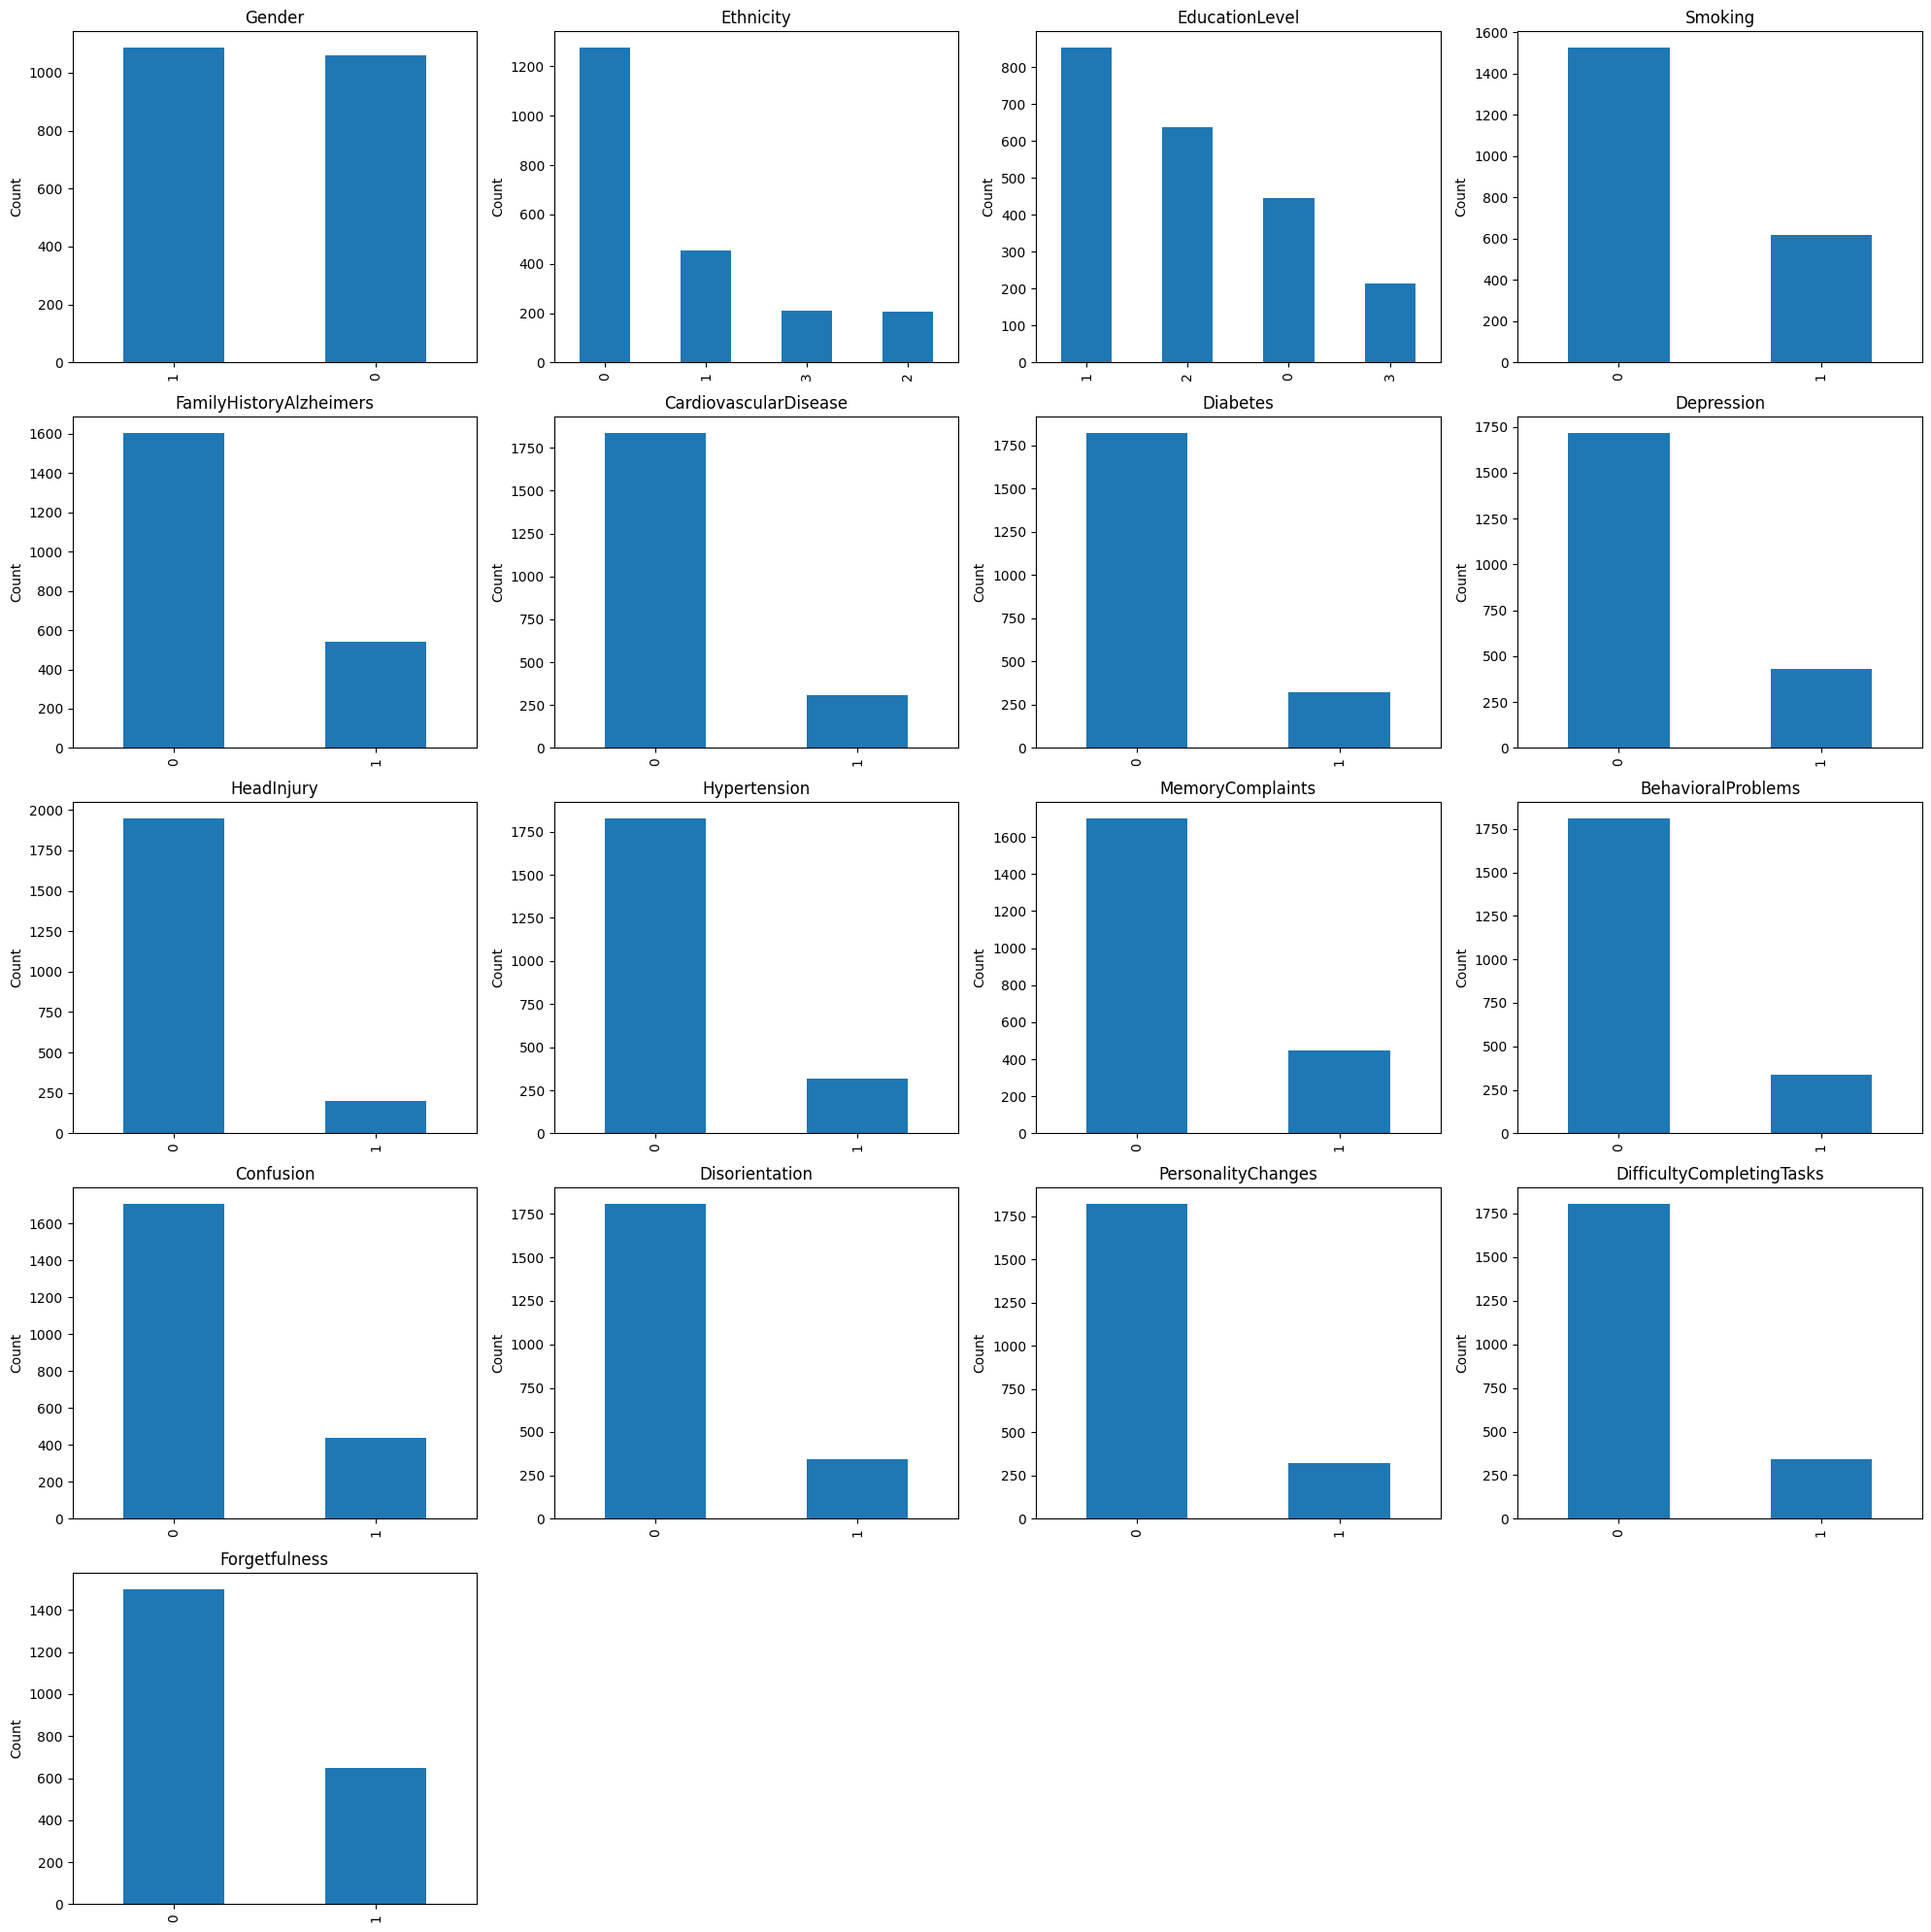

In [441]:
cat_data = ["Gender", "Ethnicity", "EducationLevel", "Smoking", "FamilyHistoryAlzheimers", "CardiovascularDisease", "Diabetes", "Depression", "HeadInjury", "Hypertension", "MemoryComplaints", "BehavioralProblems", "Confusion", "Disorientation", "PersonalityChanges", "DifficultyCompletingTasks", "Forgetfulness"]
fig, axes = plt.subplots(5, 4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(cat_data):
    data[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

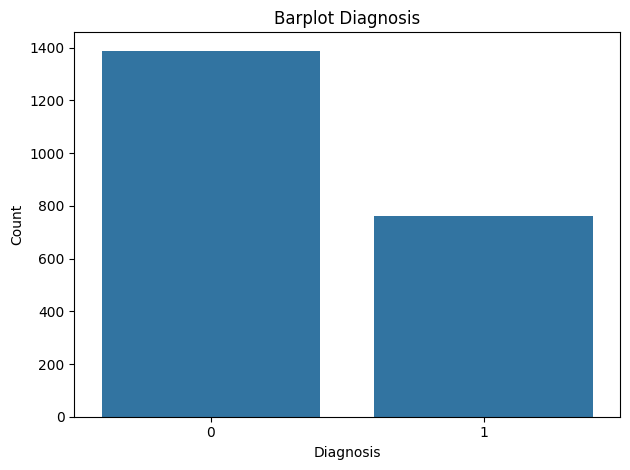

In [442]:
sns.countplot(x=data["Diagnosis"])
plt.title(f"Barplot Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Variabel diagnosis merupakan variabel target pada analisis ini. Berdasarkan visualisasi di atas diperoleh data bersifat imbalance sehingga perlu untuk mempertimbangkan melakukan penanganan data imbalance.

# Data Preparation

## Handling Missing Values

In [443]:
data.isna().sum()

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

Berdasarkan output di atas, diperoleh tidak terdapat missing value pada data.

## Handling Duplicated Data

In [444]:
data.duplicated().value_counts()

False    2149
Name: count, dtype: int64

Berdasarkan output di atas, diperoleh tidak terdapat duplicated values dalam data.

## Handling Outliers

Berdasarkan visualisasi boxplot pada bagian EDA, diperoleh tidak terdapat outlier pada data.

## Encoding Data

Pada data, dapat diidentifikasi terdapat beberapa variabel kategorik baik yang bertipe nominal maupun ordinal. Variabel-variabel katgorik yang terdapat pada data antara lain `Gender`, `Ethnicity`, `EducationLevel`, `Smoking`, `FamilyHistoryAlzheimers`, `CardiovascularDisease`, `Diabetes`, `Depression`, `HeadInjury`, `Hypertension`, `MemoryComplaints`, `BehavioralProblems`, `Confusion`, `Disorientation`, `PersonalityChanges`, `DifficultyCompletingTasks`, dan `Forgetfulness` serta `diagnosis` sebagai variabel target. Variabel kategorik yang terdapat pada data sudah dilakukan label encoding. Namun, pada analisis ini, untuk variabel kategorik tipe nominal akan diubah menjadi one-hot encoding. Hal ini bertujuan untuk memudahkan interpretasi dari feature-feature tersebut. 

Sebelum dilakukan OHE, akan di-replace terlebih dahulu menjadi nilai sebenarnya untuk memperjelas penamaan variabel saat menggunakan OHE.

In [445]:
# Mapping untuk Gender
gender_map = {0: "Male", 1: "Female"}
data["Gender"] = data["Gender"].map(gender_map)

# Mapping untuk Ethnicity
ethnicity_map = {
    0: "Caucasian",
    1: "African American",
    2: "Asian",
    3: "Other"
}
data["Ethnicity"] = data["Ethnicity"].map(ethnicity_map)

In [446]:
# One-Hot Encoding untuk Gender dan Ethnicity
data_ohe = pd.get_dummies(data, columns=["Gender", "Ethnicity"], prefix=["Gender", "Ethnicity"])
data = data_ohe.copy()
data

,PatientID,Age,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,...,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge,Gender_Female,Gender_Male,Ethnicity_African American,Ethnicity_Asian,Ethnicity_Caucasian,Ethnicity_Other
0,4751,73,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,...,1,0,0,XXXConfid,False,True,False,False,True,False
1,4752,89,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,...,0,1,0,XXXConfid,False,True,False,False,True,False
2,4753,73,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,...,1,0,0,XXXConfid,False,True,False,False,False,True
3,4754,74,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,...,0,0,0,XXXConfid,True,False,False,False,True,False
4,4755,89,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,...,1,0,0,XXXConfid,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,1,39.121757,0,1.561126,4.049964,6.555306,7.535540,0,...,0,0,1,XXXConfid,False,True,False,False,True,False
2145,6896,75,2,17.857903,0,18.767261,1.360667,2.904662,8.555256,0,...,0,0,1,XXXConfid,False,True,False,False,True,False
2146,6897,77,1,15.476479,0,4.594670,9.886002,8.120025,5.769464,0,...,0,0,1,XXXConfid,False,True,False,False,True,False
2147,6898,78,1,15.299911,0,8.674505,6.354282,1.263427,8.322874,0,...,0,1,1,XXXConfid,True,False,False,False,False,True


Selanjutnya, dari data di atas, variabel `DoctorInCharge` tidak digunakan dalam analisis, sehingga akan dihapus dari data.

In [447]:
data.drop(columns=["DoctorInCharge", "PatientID"], inplace=True)

# Modelling

## Splitting Data

In [448]:
X = data.drop(columns=['Diagnosis'])
y = data['Diagnosis']

X_train, X_test, y_train, y_test = (train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42))

Selanjutnya, akan dilakukan scaling pada data menggunakan standard scaler. Scaling dilakukan pada variabel numerik yang terdapat pada data.

In [449]:
# Numerical Pipeline
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Prepocessing Pipeline
preprocessing = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, num_data)
    ],
    remainder='passthrough'  
)

In [450]:
# Fit pada data train, lalu transform pada train dan test
X_train_scaled = preprocessing.fit_transform(X_train)
X_test_scaled = preprocessing.transform(X_test)

# Semua nama kolom
all_columns = list(X_train.columns)

# Kolom yang akan ditransformasi
transformed_columns = num_data 

# Kolom yang akan dilewati
passthrough_columns = [col for col in all_columns if col not in num_data]

# Gabungkan nama kolom setelah transformasi
new_columns = transformed_columns + passthrough_columns

# Buat DataFrame baru setelah transformasi
X_train_scaled = pd.DataFrame(X_train_scaled, columns=new_columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=new_columns, index=X_test.index)

for col in new_columns:
    X_train_scaled[col] = pd.to_numeric(X_train_scaled[col], errors='coerce')
    X_test_scaled[col] = pd.to_numeric(X_test_scaled[col], errors='coerce')

Pemodelan untuk mendeteksi penyakit alzheimers akan dilakukan menggunakan beberapa model klasifikasi sebagai berikut.

In [451]:
list_model = [
    # Decision Tree
    DecisionTreeClassifier(
        max_depth=5,             
        min_samples_split=10,   
        min_samples_leaf=5,     
        random_state=42
    ),
    # AdaBoost
    AdaBoostClassifier(
        n_estimators=100,       
        learning_rate=0.1,   
        random_state=42
    ),
    # Random Forest
    RandomForestClassifier(
        n_estimators=200,       
        max_depth=10,          
        min_samples_split=5,    
        random_state=42
    ),
    # CatBoost
    CatBoostClassifier(
        iterations=500,         
        depth=6,               
        learning_rate=0.1,
        verbose=0,
        random_state=42
    ),
    # XGBoost
    XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        random_state=42
    )
]


Pemodelan dilakukan menggunakan fungsi berikut.

In [452]:
def auto_model(list_model, x_train, y_train, x_test, y_test):
  smote = SMOTE(random_state=42)
  x_train, y_train = smote.fit_resample(x_train, y_train)

  result = []
  for model in list_model:

    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    hasil = {
       'Model' : type(model).__name__,
       'Accuracy' : accuracy,
       'F1 Score' : f1,
       'Precision' : precision,
       'Recall' : recall
       }

    result.append(hasil)
  result_all = pd.DataFrame(result)
  return result_all

# Evaluation

In [453]:
auto_model(list_model, X_train_scaled, y_train, X_test_scaled, y_test)

,Model,Accuracy,F1 Score,Precision,Recall
0,DecisionTreeClassifier,0.939535,0.914474,0.914474,0.914474
1,AdaBoostClassifier,0.918605,0.889590,0.854545,0.927632
2,RandomForestClassifier,0.934884,0.904762,0.936620,0.875000
3,CatBoostClassifier,0.951163,0.930693,0.933775,0.927632
4,XGBClassifier,0.948837,0.926174,0.945205,0.907895


Untuk pemilihan model terbaik, akan dibandingkan performa model menggunakan metrik F1-Score. Dari hasil pemodelan di atas, diperoleh model dengan nilai F1-Score tertinggi adalah `XGBoostClassifier`.

In [454]:
# Pemodelan menggunakan Model Terbaik
best = CatBoostClassifier(iterations=500, depth=6, learning_rate=0.1, verbose=0, random_state=42) # model terbaik
best.fit(X_train_scaled, y_train) # fitting model terbaik menggunakan data latih

# Predict the test set
Y_pred = best.predict(X_test_scaled)

# Check the classification report
print(classification_report(y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       278
           1       0.94      0.92      0.93       152

    accuracy                           0.95       430
   macro avg       0.95      0.94      0.95       430
weighted avg       0.95      0.95      0.95       430



Berdasarkan classification report di atas, hasil pemodelan telah memberikan performa yang baik. Dengan demikian, pemodelan tidak dilanjutkan dengan melakukan hyperparameter tuning.

# Post Analysis

Post analysis dilakukan menggunakan feature importance untuk melihat kontribusi setiap fitur dalam model

In [455]:
# Nilai feature importance dari model terbaik
importances = best.get_feature_importance()

# DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
feature_importance_df

,Feature,Importance
13,FunctionalAssessment,19.741240
14,ADL,18.294980
12,MMSE,13.996982
23,MemoryComplaints,12.752263
24,BehavioralProblems,8.664721
4,DietQuality,2.591059
0,Age,2.354410
8,CholesterolTotal,2.229444
6,SystolicBP,2.218295
5,SleepQuality,2.156447


C:\Users\USER\AppData\Local\Temp\ipykernel_21296\3266340266.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


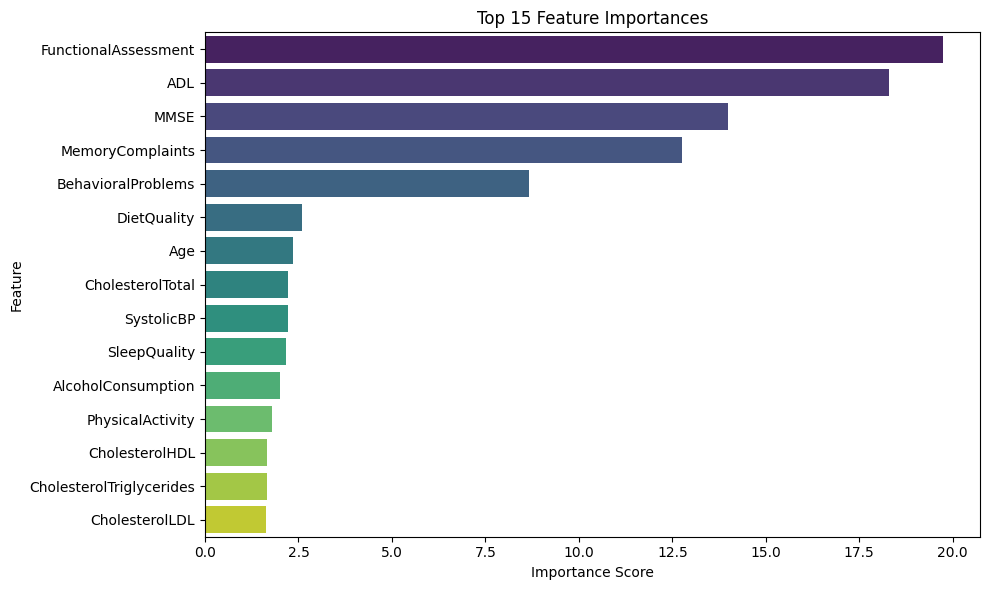

In [456]:
# Visualisasi
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()